# Google Play Store Analytics

## Project Overview
This project explores the Google Play Store dataset to identify insights into app categories, ratings, installations, pricing, and user engagement. The analysis uses Python to clean, process, visualize, and interpret app data for business insights.

## Project Workflow
1. **Data Loading**
2. **Data Preprocessing**
3. **Feature Engineering**
4. **Exploratory Data Analysis (EDA)**
5. **Business Insights**
6. **Business Recommendations**
7. **Automated Reporting**

## Dataset
[Google Play Store Apps Dataset – Kaggle](https://www.kaggle.com/datasets/lava18/google-play-store-apps)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


#Data Loading & Initial Inspection

###Load dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving googleplaystore.csv to googleplaystore.csv


In [ ]:
df = pd.read_csv("googleplaystore.csv")

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


###Basic dataset inspection

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (10841, 13)

Column Names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 


###Check missing values

In [ ]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Rating            1474
Type                 1
Content Rating       1
Current Ver          8
Android Ver          3
dtype: int64


###Check duplicates

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 483


###Statistical overview

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,10841,9660,ROBLOX,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,10841,34,FAMILY,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9367.0,NaN,NaN,NaN,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0
Reviews,10841,6002,0,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,10841,462,Varies with device,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installs,10841,22,"1,000,000+",1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10840,3,Free,10039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,10841,93,0,10040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content Rating,10840,6,Everyone,8714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,10841,120,Tools,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Result:**

Statistical overview generated — Rating range 1.0–19.0 (invalid max detected),
Free apps = 10,039, top category = FAMILY (1,972 apps).

#Data Preprocessing

###Create working dataset

In [ ]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Original shape: (10841, 13)
Working dataset shape: (10841, 13)


###Removing duplicate records

In [ ]:
duplicates = df_clean.duplicated().sum()

print("Duplicate rows found:", duplicates)

df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows found: 483
Shape after removing duplicates: (10358, 13)


**Result:**

483 duplicate rows removed — shape changed from **(10841, 13)** to **(10358, 13)**.

###Investigating the abnormal Rating

In [ ]:
invalid_ratings = df_clean[
    (df_clean["Rating"] < 1) | (df_clean["Rating"] > 5)
]

print("Invalid rating records:", len(invalid_ratings))

invalid_ratings[["App", "Category", "Rating"]]

Invalid rating records: 1


,App,Category,Rating
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0


###Handle invalid ratings

In [ ]:
df_clean.loc[
    (df_clean["Rating"] < 1) | (df_clean["Rating"] > 5),
    "Rating"
] = np.nan

print("Invalid ratings converted to NaN.")

Invalid ratings converted to NaN.


In [ ]:
print("Missing ratings:", df_clean["Rating"].isna().sum())

Missing ratings: 1466


###Convert Numeric Columns

In [ ]:
df_clean["Reviews"] = pd.to_numeric(
    df_clean["Reviews"],
    errors="coerce"
)

In [ ]:
print(df_clean["Reviews"].dtype)

float64


**Result:**

`Reviews` column converted to **float64** numeric type.

###Find the problematic row 'Free' and fixing it

In [ ]:
df_clean[df_clean["Installs"].str.contains("Free", na=False)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,NaN,NaN,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [ ]:
df_clean = df_clean[
    ~df_clean["Installs"].str.contains("Free", na=False)
].copy()

print("Shape after removing malformed row:", df_clean.shape)

Shape after removing malformed row: (10357, 13)


In [ ]:
df_clean["Installs"] = (
    df_clean["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(float)
)

print(df_clean["Installs"].head())
print("\nData type:", df_clean["Installs"].dtype)

0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
Name: Installs, dtype: float64

Data type: float64


**Result:**

`Installs` cleaned — commas and "+" removed, dtype = **float64**, 0 missing values.

In [ ]:
print(
    df_clean["Installs"]
    .isna()
    .sum()
)

print(
    df_clean["Installs"]
    .apply(lambda x: isinstance(x, (int, float)))
    .all()
)

0
True


In [ ]:
df_clean["Installs"].head()

,Installs
0,10000.0
1,500000.0
2,5000000.0
3,50000000.0
4,100000.0


###Price(Cleaning the $ symbol)

In [ ]:
df_clean["Price"] = (
    df_clean["Price"]
    .str.replace("$", "", regex=False)
    .astype(float)
)

In [ ]:
df_clean["Price"].head()

,Price
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


**Result:**

`Price` cleaned — "$" symbol removed, dtype = **float64**.

###Clean Size

In [ ]:
# We will convert everything to MB.
def convert_size(value):
    if value == "Varies with device":
        return np.nan

    if isinstance(value, str):
        if value.endswith("M"):
            return float(value[:-1])
        elif value.endswith("k"):
            return float(value[:-1]) / 1024

    return np.nan


df_clean["Size_MB"] = df_clean["Size"].apply(convert_size)

In [ ]:
df_clean[["Size", "Size_MB"]].head(10)

,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


**Result:**

 New `Size_MB` column created by converting all sizes to MB (e.g., 19M → 19.0, 8.7M → 8.7).

###Converting Date

In [ ]:
df_clean["Last Updated"] = pd.to_datetime(
    df_clean["Last Updated"],
    errors="coerce"
)

In [ ]:
print(df_clean["Last Updated"].dtype)

datetime64[ns]


**Result:**

`Last Updated` converted to **datetime64[ns]** format.

###Final preprocessing check

In [ ]:
print("Final shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nData types:")
print(df_clean.dtypes)

Final shape: (10357, 14)

Missing values:
App                  0
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
Size_MB           1526
dtype: int64

Data types:
App                       object
Category                  object
Rating                   float64
Reviews                  float64
Size                      object
Installs                 float64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
Size_MB                  float64
dtype: object


**Result:**

 Final preprocessing check — shape = **(10357, 14)**; Rating missing = 1465, Size_MB missing = 1526.

In [ ]:
invalid_ratings

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [ ]:
print("Final shape:", df_clean.shape)
print(df_clean.isnull().sum())
print(df_clean.dtypes)

Final shape: (10357, 14)
App                  0
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
Size_MB           1526
dtype: int64
App                       object
Category                  object
Rating                   float64
Reviews                  float64
Size                      object
Installs                 float64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
Size_MB                  float64
dtype: object


####Removing ths corrupted row


In [ ]:
df_clean = df_clean.drop(index=10472, errors="ignore").copy()

print("Shape after removing corrupted row:", df_clean.shape)

Shape after removing corrupted row: (10357, 14)


###Handle remaining categorical missing values

In [ ]:
categorical_columns = [
    "Type",
    "Content Rating",
    "Current Ver",
    "Android Ver"
]

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

**Result:**

Missing categorical values in Type, Content Rating, Current Ver, Android Ver filled using **mode**.

###Handle missing Size_MB

In [ ]:
size_median = df_clean["Size_MB"].median()

df_clean["Size_MB"] = df_clean["Size_MB"].fillna(size_median)

print("Median app size:", size_median)
print("Remaining missing Size_MB:", df_clean["Size_MB"].isna().sum())

Median app size: 13.0
Remaining missing Size_MB: 0


**Result:**

Missing `Size_MB` values filled with **median = 13.0 MB** — 0 missing remaining.

###Handle missing ratings

In [ ]:
# Uisng the median
rating_median = df_clean["Rating"].median()

df_clean["Rating"] = df_clean["Rating"].fillna(rating_median)

print("Median rating:", rating_median)
print("Remaining missing ratings:", df_clean["Rating"].isna().sum())

Median rating: 4.3
Remaining missing ratings: 0


**Result:**

 Missing `Rating` values filled with **median = 4.3** — 0 missing remaining.

###Final missing-value check

In [ ]:
print("Final shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("Remaining duplicate rows:", df_clean.duplicated().sum())

Final shape: (10357, 14)

Missing values:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
Size_MB           0
dtype: int64
Remaining duplicate rows: 0


**Result:**

 Final check — shape = **(10357, 14)**, **0 missing values**, **0 duplicate rows**.

###Validate numeric columns

In [ ]:
print(df_clean[[
    "Rating",
    "Reviews",
    "Installs",
    "Price",
    "Size_MB"
]].describe())

             Rating       Reviews      Installs         Price       Size_MB
count  10357.000000  1.035700e+04  1.035700e+04  10357.000000  10357.000000
mean       4.203737  4.059046e+05  1.415776e+07      1.030800     20.066346
std        0.485594  2.696778e+06  8.023955e+07     16.278625     21.019993
min        1.000000  0.000000e+00  0.000000e+00      0.000000      0.008301
25%        4.100000  3.200000e+01  1.000000e+03      0.000000      5.700000
50%        4.300000  1.680000e+03  1.000000e+05      0.000000     13.000000
75%        4.500000  4.641600e+04  1.000000e+06      0.000000     26.000000
max        5.000000  7.815831e+07  1.000000e+09    400.000000    100.000000


**Result:**

Numeric validation — Rating: 1.0–5.0 (mean 4.20), Installs: 0–1B (mean 14.1M), Price: 0–400 (mean 1.03).

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10357 non-null  object        
 1   Category        10357 non-null  object        
 2   Rating          10357 non-null  float64       
 3   Reviews         10357 non-null  float64       
 4   Size            10357 non-null  object        
 5   Installs        10357 non-null  float64       
 6   Type            10357 non-null  object        
 7   Price           10357 non-null  float64       
 8   Content Rating  10357 non-null  object        
 9   Genres          10357 non-null  object        
 10  Last Updated    10357 non-null  datetime64[ns]
 11  Current Ver     10357 non-null  object        
 12  Android Ver     10357 non-null  object        
 13  Size_MB         10357 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(8)
memory usage: 1

In [ ]:
df_clean.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8


In [ ]:
print(10472 in df_clean.index)

False


#Feature Engineering

###Extract Year and Month

In [ ]:
df_clean["Year"] = df_clean["Last Updated"].dt.year
df_clean["Month"] = df_clean["Last Updated"].dt.month

print(df_clean[["Last Updated", "Year", "Month"]].head())

  Last Updated  Year  Month
0   2018-01-07  2018      1
1   2018-01-15  2018      1
2   2018-08-01  2018      8
3   2018-06-08  2018      6
4   2018-06-20  2018      6


**Result:**

New features `Year` and `Month` extracted from `Last Updated` column.

###Create Is_Paid

In [ ]:
df_clean["Is_Paid"] = np.where(
    df_clean["Type"] == "Paid",
    1,
    0
)

print(df_clean["Is_Paid"].value_counts())

Is_Paid
0    9592
1     765
Name: count, dtype: int64


In [ ]:
df_clean[["Type", "Is_Paid"]].head(10)

,Type,Is_Paid
0,Free,0
1,Free,0
2,Free,0
3,Free,0
4,Free,0
5,Free,0
6,Free,0
7,Free,0
8,Free,0
9,Free,0


**Result:**

New feature `Is_Paid` created — 0 (Free) = **9,592**, 1 (Paid) = **765**.

###Creating Install Categories

In [ ]:
install_bins = [
    -1,
    1000,
    10000,
    100000,
    1000000,
    10000000,
    100000000,
    np.inf
]

install_labels = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High",
    "Extremely High",
    "Massive"
]

df_clean["Install_Category"] = pd.cut(
    df_clean["Installs"],
    bins=install_bins,
    labels=install_labels
)

In [ ]:
df_clean["Install_Category"].value_counts()

,count
Install_Category,
Very Low,2681
High,2005
Very High,1815
Moderate,1603
Low,1502
Extremely High,641
Massive,110


**Result:**

New feature `Install_Category` created with 7 bins — Very Low (2681), High (2005), Very High (1815), Moderate (1603), Low (1502), Extremely High (641), Massive (110).

###Creating Price Categories

Most apps are free, so we'll separate free apps from paid apps and then categorize paid apps by price.

In [ ]:
def price_category(price):
    if price == 0:
        return "Free"
    elif price <= 5:
        return "Low"
    elif price <= 20:
        return "Moderate"
    else:
        return "High"


df_clean["Price_Category"] = df_clean["Price"].apply(price_category)

In [ ]:
df_clean["Price_Category"].value_counts()

,count
Price_Category,
Free,9592
Low,603
Moderate,122
High,40


**Result:**

New feature `Price_Category` created — Free (9592), Low (603), Moderate (122), High (40).

###Creating Review-to-Install Ratio

In [ ]:
df_clean["Review_Install_Ratio"] = np.where(
    df_clean["Installs"] > 0,
    (df_clean["Reviews"] / df_clean["Installs"]) * 100,
    0
)

In [ ]:
df_clean[
    ["App", "Reviews", "Installs", "Review_Install_Ratio"]
].head(10)

,App,Reviews,Installs,Review_Install_Ratio
0,Photo Editor & Candy Camera & Grid & ScrapBook,159.0,10000.0,1.590000
1,Coloring book moana,967.0,500000.0,0.193400
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",87510.0,5000000.0,1.750200
3,Sketch - Draw & Paint,215644.0,50000000.0,0.431288
4,Pixel Draw - Number Art Coloring Book,967.0,100000.0,0.967000
5,Paper flowers instructions,167.0,50000.0,0.334000
6,Smoke Effect Photo Maker - Smoke Editor,178.0,50000.0,0.356000
7,Infinite Painter,36815.0,1000000.0,3.681500
8,Garden Coloring Book,13791.0,1000000.0,1.379100
9,Kids Paint Free - Drawing Fun,121.0,10000.0,1.210000


**Result:**

New feature `Review_Install_Ratio` created — mean ≈ 3.82%, max = 400%.

###Creating Days Since Last Update

In [ ]:
reference_date = df_clean["Last Updated"].max()

df_clean["Days_Since_Update"] = (
    reference_date - df_clean["Last Updated"]
).dt.days

print("Reference date:", reference_date)
df_clean[
    ["App", "Last Updated", "Days_Since_Update"]
].head()

Reference date: 2018-08-08 00:00:00


,App,Last Updated,Days_Since_Update
0,Photo Editor & Candy Camera & Grid & ScrapBook,2018-01-07,213
1,Coloring book moana,2018-01-15,205
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",2018-08-01,7
3,Sketch - Draw & Paint,2018-06-08,61
4,Pixel Draw - Number Art Coloring Book,2018-06-20,49


**Result:**

New feature `Days_Since_Update` created using reference date **2018-08-08** — range 0–3001 days.

###Checking the new dataset

In [ ]:
print("Dataset shape:", df_clean.shape)

print("\nNew features:")
print([
    "Year",
    "Month",
    "Is_Paid",
    "Install_Category",
    "Price_Category",
    "Review_Install_Ratio",
    "Days_Since_Update"
])

Dataset shape: (10357, 21)

New features:
['Year', 'Month', 'Is_Paid', 'Install_Category', 'Price_Category', 'Review_Install_Ratio', 'Days_Since_Update']


**Result:**

Final dataset shape = **(10357, 21)** — 7 new features added successfully.

In [ ]:
df_clean.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Current Ver,Android Ver,Size_MB,Year,Month,Is_Paid,Install_Category,Price_Category,Review_Install_Ratio,Days_Since_Update
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,...,1.0.0,4.0.3 and up,19.0,2018,1,0,Low,Free,1.590000,213
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,...,2.0.0,4.0.3 and up,14.0,2018,1,0,High,Free,0.193400,205
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,...,1.2.4,4.0.3 and up,8.7,2018,8,0,Very High,Free,1.750200,7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0.0,Teen,Art & Design,...,Varies with device,4.2 and up,25.0,2018,6,0,Extremely High,Free,0.431288,61
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,...,1.1,4.4 and up,2.8,2018,6,0,Moderate,Free,0.967000,49


###Final feature-engineering validation

In [ ]:
print(df_clean[
    [
        "Year",
        "Month",
        "Is_Paid",
        "Install_Category",
        "Price_Category",
        "Review_Install_Ratio",
        "Days_Since_Update"
    ]
].isnull().sum())

Year                    0
Month                   0
Is_Paid                 0
Install_Category        0
Price_Category          0
Review_Install_Ratio    0
Days_Since_Update       0
dtype: int64


**Result:**

Feature validation — 0 missing values in all 7 new features.

In [ ]:
df_clean.describe()

,Rating,Reviews,Installs,Price,Last Updated,Size_MB,Year,Month,Is_Paid,Review_Install_Ratio,Days_Since_Update
count,10357.000000,1.035700e+04,1.035700e+04,10357.000000,10357,10357.000000,10357.000000,10357.000000,10357.000000,10357.000000,10357.000000
mean,4.203737,4.059046e+05,1.415776e+07,1.030800,2017-11-14 09:25:19.320266496,20.066346,2017.382929,6.397026,0.073863,3.815652,266.607415
min,1.000000,0.000000e+00,0.000000e+00,0.000000,2010-05-21 00:00:00,0.008301,2010.000000,1.000000,0.000000,0.000000,0.000000
25%,4.100000,3.200000e+01,1.000000e+03,0.000000,2017-09-03 00:00:00,5.700000,2017.000000,5.000000,0.000000,0.774000,20.000000
50%,4.300000,1.680000e+03,1.000000e+05,0.000000,2018-05-20 00:00:00,13.000000,2018.000000,7.000000,0.000000,1.775420,80.000000
75%,4.500000,4.641600e+04,1.000000e+06,0.000000,2018-07-19 00:00:00,26.000000,2018.000000,8.000000,0.000000,3.960900,339.000000
max,5.000000,7.815831e+07,1.000000e+09,400.000000,2018-08-08 00:00:00,100.000000,2018.000000,12.000000,1.000000,400.000000,3001.000000
std,0.485594,2.696778e+06,8.023955e+07,16.278625,NaN,21.019993,1.112766,2.606359,0.261561,9.722613,398.628012


#Exploratory Data Analysis

##Category Distribution

###Which app categories have the largest number of apps?

In [ ]:
category_counts = df_clean["Category"].value_counts()

print("Number of categories:", category_counts.shape[0])
print("\nTop 10 categories:")
print(category_counts.head(10))

Number of categories: 33

Top 10 categories:
Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64


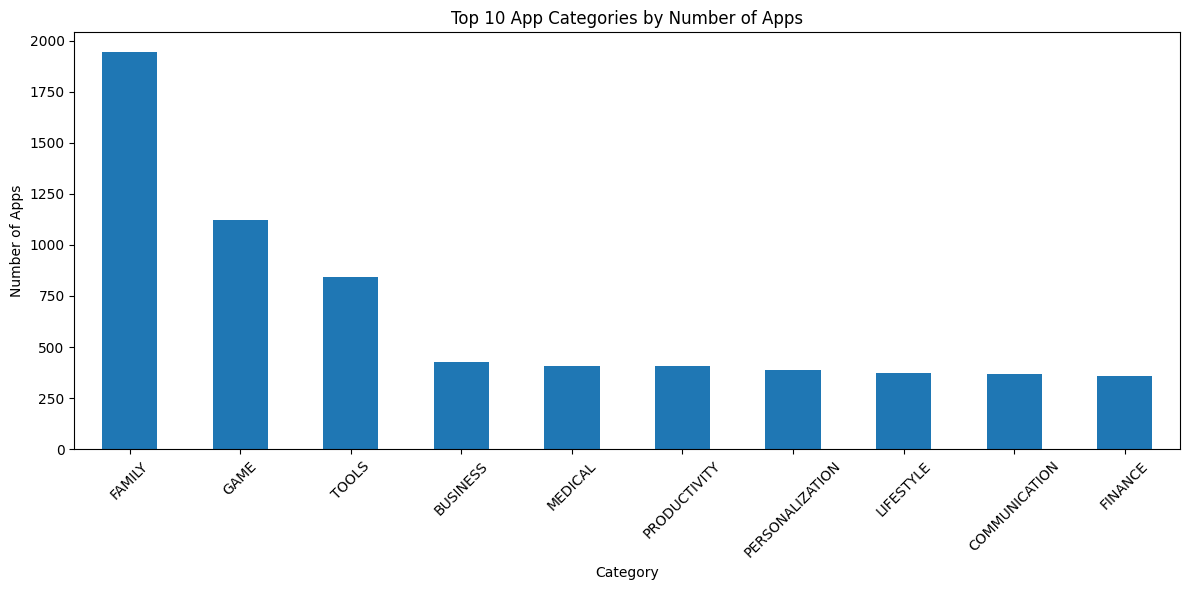

In [ ]:
plt.figure(figsize=(12, 6))

category_counts.head(10).plot(kind="bar")

plt.title("Top 10 App Categories by Number of Apps")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

###**Result:**

33 categories found; **FAMILY (1943)** is the largest, followed by GAME (1121) and TOOLS (843).

##Rating Analysis

###How are apps distributed by user rating?

In [ ]:
rating_stats = df_clean["Rating"].describe()

print(rating_stats)

count    10357.000000
mean         4.203737
std          0.485594
min          1.000000
25%          4.100000
50%          4.300000
75%          4.500000
max          5.000000
Name: Rating, dtype: float64


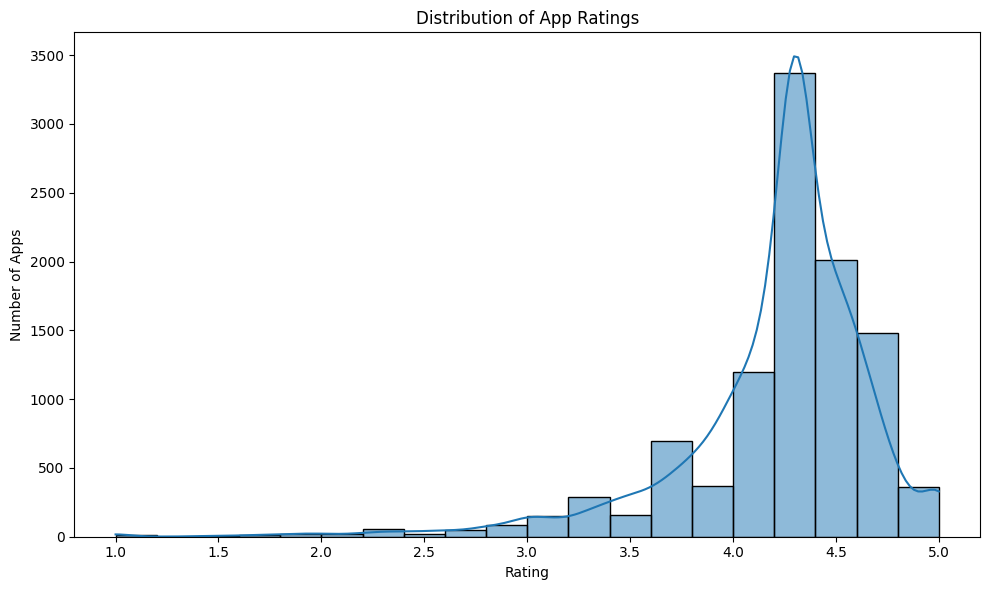

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_clean["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.tight_layout()

plt.show()

###**Result:**

Rating distribution — mean = **4.20**, median = **4.30**, std = 0.49; most apps rated between 4.0–4.5.

##Average Rating by Category

###We will examine whether some categories have higher average ratings

In [ ]:
category_rating = (
    df_clean.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 categories by average rating:")
print(category_rating.head(10))

Top 10 categories by average rating:
Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.355385
BOOKS_AND_REFERENCE    4.336522
PERSONALIZATION        4.327062
PARENTING              4.300000
BEAUTY                 4.283019
GAME                   4.282070
HEALTH_AND_FITNESS     4.266993
SOCIAL                 4.260714
Name: Rating, dtype: float64


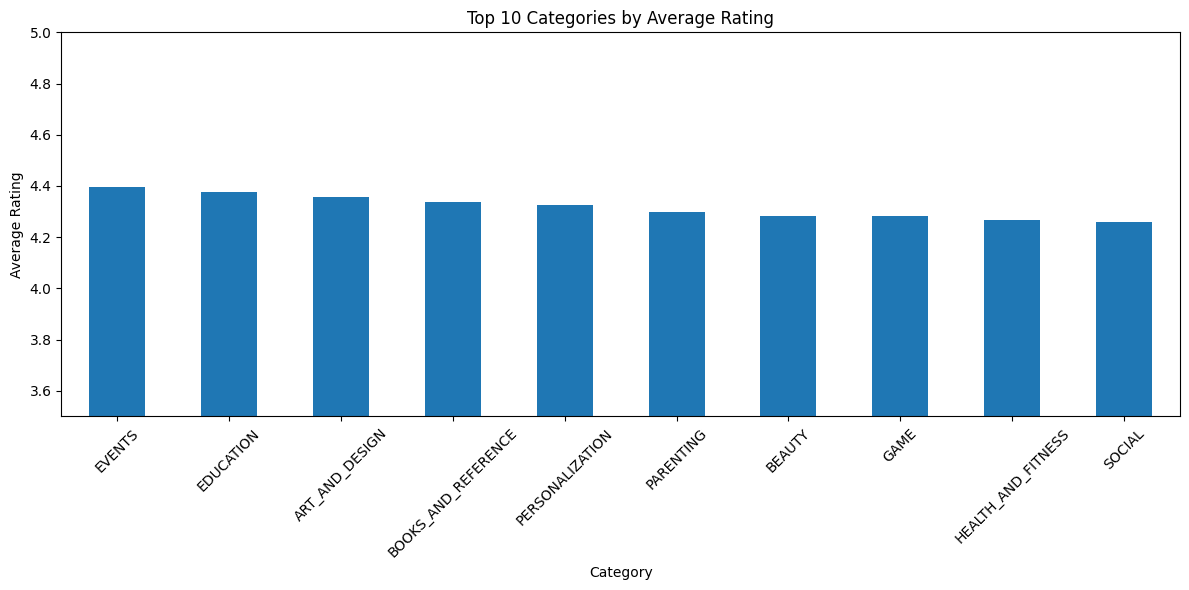

In [ ]:
plt.figure(figsize=(12, 6))

category_rating.head(10).plot(kind="bar")

plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.ylim(3.5, 5)

plt.tight_layout()
plt.show()

###**Result:**

Top-rated categories :-
- **EVENTS (4.40)**
- EDUCATION (4.38)
- ART_AND_DESIGN (4.36)
- BOOKS_AND_REFERENCE (4.34)
- PERSONALIZATION (4.33).

##Installs by Category

###Which app categories attract the most installations?

In [ ]:
category_installs = (
    df_clean.groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 categories by total installs:")
print(category_installs.head(10))

Top 10 categories by total installs:
Category
GAME                  3.154402e+10
COMMUNICATION         2.415228e+10
SOCIAL                1.251387e+10
PRODUCTIVITY          1.246309e+10
TOOLS                 1.145277e+10
FAMILY                1.004169e+10
PHOTOGRAPHY           9.721248e+09
TRAVEL_AND_LOCAL      6.361887e+09
VIDEO_PLAYERS         6.222003e+09
NEWS_AND_MAGAZINES    5.393218e+09
Name: Installs, dtype: float64


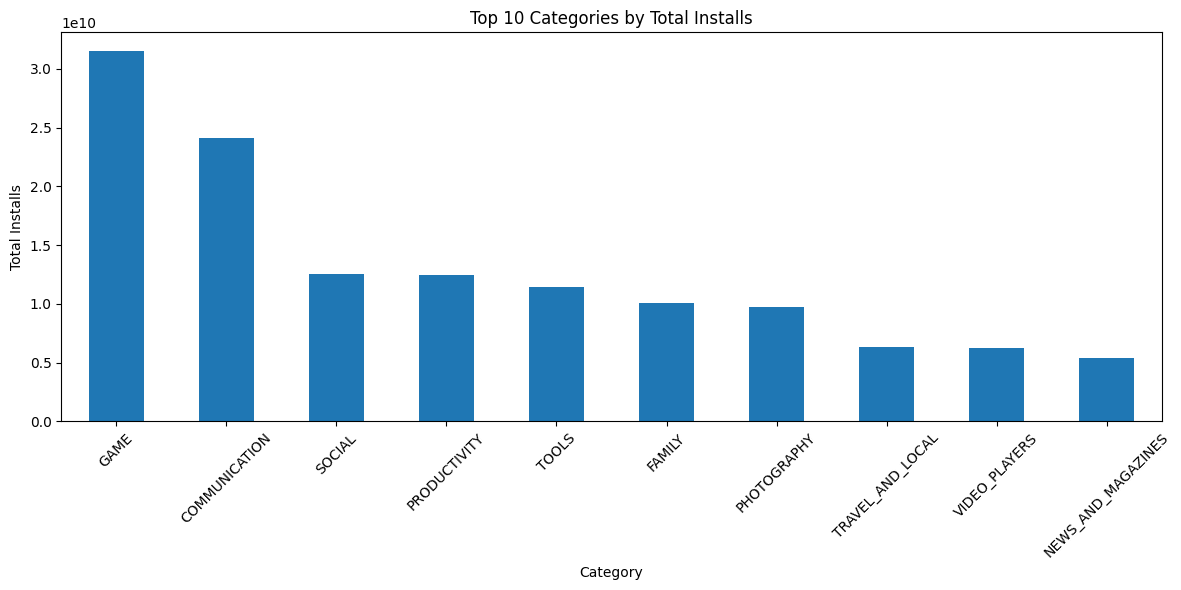

In [ ]:
plt.figure(figsize=(12, 6))

category_installs.head(10).plot(kind="bar")

plt.title("Top 10 Categories by Total Installs")
plt.xlabel("Category")
plt.ylabel("Total Installs")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

###**Result:**

Top categories by total installs:-
- **GAME (31.5B)**
- COMMUNICATION (24.2B)
- SOCIAL (12.5B)
- PRODUCTIVITY (12.5B)
- TOOLS (11.5B)

##Free vs Paid Apps

###How does the Play Store app market differ between free and paid apps?

In [ ]:
type_counts = df_clean["Type"].value_counts()

print("Free vs Paid apps:")
print(type_counts)

Free vs Paid apps:
Type
Free    9592
Paid     765
Name: count, dtype: int64


###**Result:**

Free vs Paid split:-
- **Free: 9,592 (92.6%)** vs **Paid: 765 (7.4%)**

In [ ]:
type_summary = (
    df_clean.groupby("Type")
    .agg(
        App_Count=("App", "count"),
        Average_Rating=("Rating", "mean"),
        Average_Reviews=("Reviews", "mean"),
        Average_Installs=("Installs", "mean"),
        Average_Price=("Price", "mean")
    )
)

print(type_summary)

      App_Count  Average_Rating  Average_Reviews  Average_Installs  \
Type                                                                 
Free       9592         4.19852    437327.995309      1.527968e+07   
Paid        765         4.26915     11900.550327      9.049135e+04   

      Average_Price  
Type                 
Free       0.000000  
Paid      13.955556  


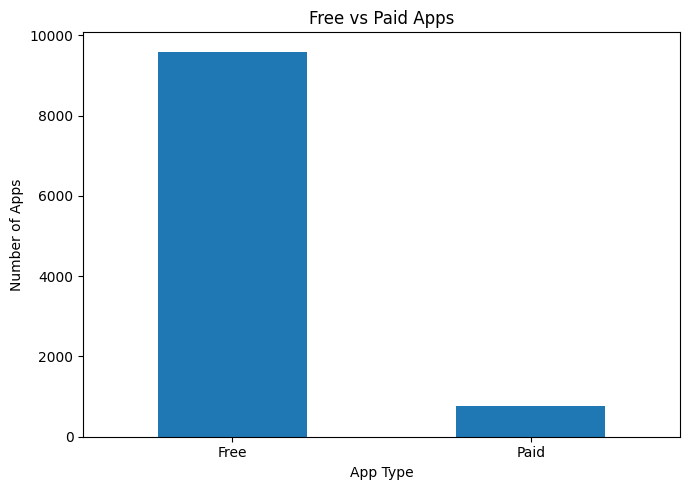

In [ ]:
plt.figure(figsize=(7, 5))

type_counts.plot(kind="bar")

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

###**Result:**

- Free apps avg rating = 4.20 / avg installs = 15.3M
- Paid apps avg rating = 4.27 / avg installs = 90.5K / avg price = $13.96.

##Reviews vs Installs

###Do apps with more installations generally receive more user reviews?

In [ ]:
# Calculating Correlation
correlation = df_clean["Reviews"].corr(df_clean["Installs"])

print("Correlation between Reviews and Installs:", correlation)


Correlation between Reviews and Installs: 0.6349973300975319


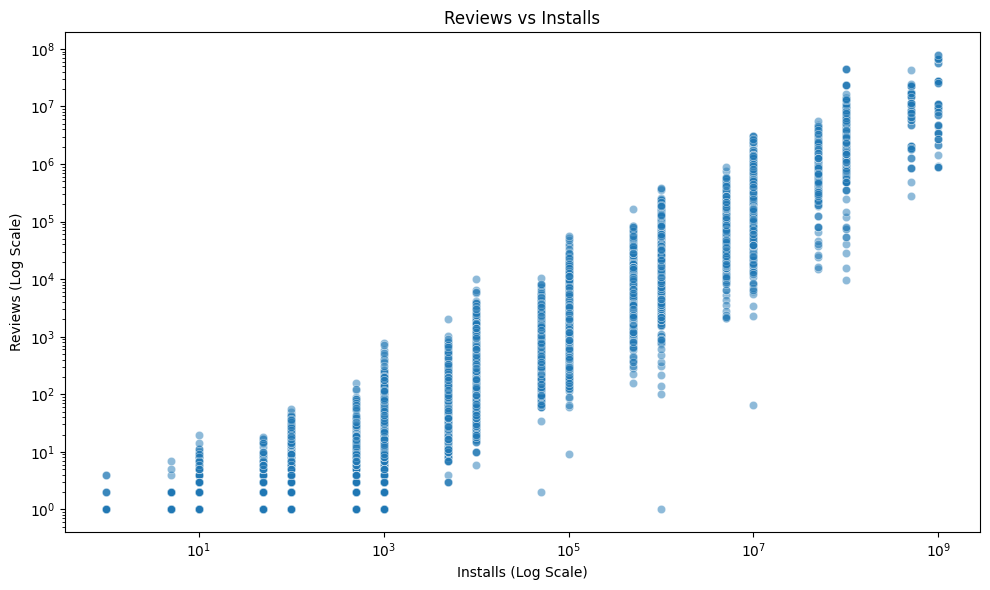

In [ ]:
# creating scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="Installs",
    y="Reviews",
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title("Reviews vs Installs")
plt.xlabel("Installs (Log Scale)")
plt.ylabel("Reviews (Log Scale)")

plt.tight_layout()
plt.show()

###**Result:**

 Correlation between Reviews and Installs = **0.635** => moderate positive relationship.

##Apps by Year

###How has the number of apps in the dataset changed over the years?

In [ ]:
year_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

print("Number of apps by year:")
print(year_counts)

Number of apps by year:
Year
2010       1
2011      15
2012      26
2013     108
2014     204
2015     454
2016     789
2017    1826
2018    6934
Name: count, dtype: int64


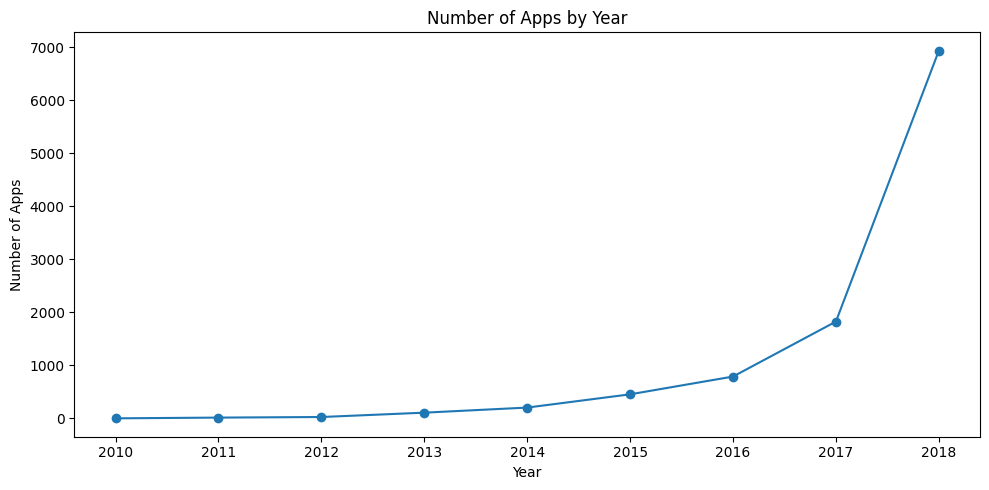

In [ ]:
plt.figure(figsize=(10, 5))

year_counts.plot(kind="line", marker="o")

plt.title("Number of Apps by Year")
plt.xlabel("Year")
plt.ylabel("Number of Apps")
plt.xticks(year_counts.index)

plt.tight_layout()
plt.show()

###**Result:**

 Apps by year => steady growth from 2010 (1 app) to **2018 (6,934 apps)**.

#Business Insights

In [ ]:
# Key business metrics for automated insights

top_category = category_counts.idxmax()
top_category_apps = category_counts.max()

top_install_category = category_installs.idxmax()
top_install_value = category_installs.max()

highest_rated_category = category_rating.idxmax()
highest_category_rating = category_rating.max()

free_apps = (df_clean["Type"] == "Free").sum()
paid_apps = (df_clean["Type"] == "Paid").sum()

free_avg_installs = df_clean.loc[
    df_clean["Type"] == "Free", "Installs"
].mean()

paid_avg_installs = df_clean.loc[
    df_clean["Type"] == "Paid", "Installs"
].mean()

free_avg_rating = df_clean.loc[
    df_clean["Type"] == "Free", "Rating"
].mean()

paid_avg_rating = df_clean.loc[
    df_clean["Type"] == "Paid", "Rating"
].mean()

latest_year = df_clean["Year"].max()
latest_year_apps = (df_clean["Year"] == latest_year).sum()

print("KEY BUSINESS INSIGHTS")
print("-" * 40)

print(f"1. Largest app category: {top_category} ({top_category_apps:,} apps)")
print(f"2. Category with highest total installs: {top_install_category} ({top_install_value:,.0f} installs)")
print(f"3. Highest average-rated category: {highest_rated_category} ({highest_category_rating:.2f})")
print(f"4. Free apps: {free_apps:,}")
print(f"5. Paid apps: {paid_apps:,}")
print(f"6. Average installs - Free apps: {free_avg_installs:,.0f}")
print(f"7. Average installs - Paid apps: {paid_avg_installs:,.0f}")
print(f"8. Average rating - Free apps: {free_avg_rating:.2f}")
print(f"9. Average rating - Paid apps: {paid_avg_rating:.2f}")
print(f"10. Apps updated in {latest_year}: {latest_year_apps:,}")
print(f"11. Reviews-Installs correlation: {correlation:.3f}")

KEY BUSINESS INSIGHTS
----------------------------------------
1. Largest app category: FAMILY (1,943 apps)
2. Category with highest total installs: GAME (31,544,024,415 installs)
3. Highest average-rated category: EVENTS (4.40)
4. Free apps: 9,592
5. Paid apps: 765
6. Average installs - Free apps: 15,279,680
7. Average installs - Paid apps: 90,491
8. Average rating - Free apps: 4.20
9. Average rating - Paid apps: 4.27
10. Apps updated in 2018: 6,934
11. Reviews-Installs correlation: 0.635


#Business Recommendations

In [ ]:
recommendations = [
    "Focus market analysis on high-reach categories such as GAME, COMMUNICATION, and SOCIAL.",
    "For new apps, prioritize user engagement and review generation because installs and reviews show a positive association.",
    "Consider a freemium or free-first strategy, since free apps make up the large majority of the analyzed dataset.",
    "For paid apps, emphasize clear value and differentiated features because the paid segment is much smaller than the free segment.",
    "Monitor highly rated categories such as EVENTS, EDUCATION, and ART_AND_DESIGN for potential opportunities.",
    "Keep apps regularly updated to maintain relevance and user engagement."
]

print("BUSINESS RECOMMENDATIONS")
print("-" * 40)

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

BUSINESS RECOMMENDATIONS
----------------------------------------
1. Focus market analysis on high-reach categories such as GAME, COMMUNICATION, and SOCIAL.
2. For new apps, prioritize user engagement and review generation because installs and reviews show a positive association.
3. Consider a freemium or free-first strategy, since free apps make up the large majority of the analyzed dataset.
4. For paid apps, emphasize clear value and differentiated features because the paid segment is much smaller than the free segment.
5. Monitor highly rated categories such as EVENTS, EDUCATION, and ART_AND_DESIGN for potential opportunities.
6. Keep apps regularly updated to maintain relevance and user engagement.


#Conclusion

In [ ]:
conclusion = """
This analysis examined 10,357 cleaned Google Play Store app records to understand
category distribution, ratings, installations, pricing, and user engagement.

The analysis shows that FAMILY is the largest category by number of apps, while
GAME has the highest total number of installations. The dataset is dominated by
free apps, with 9,592 free apps compared with 765 paid apps. Paid apps have a
slightly higher average rating, while free apps have substantially higher average
install counts.

A correlation of approximately 0.635 between reviews and installs indicates a
moderate positive association between app reach and user reviews. The number of
app records also increases substantially in the later years of the dataset,
with 2018 containing the largest number of records.

Overall, the analysis provides a data-driven view of the Google Play Store
landscape and highlights category reach, pricing models, ratings, and engagement
as useful factors for business decision-making.
"""

print("CONCLUSION")
print("-" * 40)
print(conclusion)

CONCLUSION
----------------------------------------

This analysis examined 10,357 cleaned Google Play Store app records to understand
category distribution, ratings, installations, pricing, and user engagement.

The analysis shows that FAMILY is the largest category by number of apps, while
GAME has the highest total number of installations. The dataset is dominated by
free apps, with 9,592 free apps compared with 765 paid apps. Paid apps have a
slightly higher average rating, while free apps have substantially higher average
install counts.

A correlation of approximately 0.635 between reviews and installs indicates a
moderate positive association between app reach and user reviews. The number of
app records also increases substantially in the later years of the dataset,
with 2018 containing the largest number of records.

Overall, the analysis provides a data-driven view of the Google Play Store
landscape and highlights category reach, pricing models, ratings, and engagement
as usef

#Automatically Report genertaion

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create folder for visualizations
os.makedirs("visualizations", exist_ok=True)

# 1. Category Distribution
plt.figure(figsize=(12, 6))
category_counts.head(10).plot(kind="bar")
plt.title("Top 10 App Categories by Number of Apps")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("visualizations/category_distribution.png", dpi=200, bbox_inches="tight")
plt.close()


# 2. Rating Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_clean["Rating"], bins=20, kde=True)
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.savefig("visualizations/rating_distribution.png", dpi=200, bbox_inches="tight")
plt.close()


# 3. Average Rating by Category
plt.figure(figsize=(12, 6))
category_rating.head(10).plot(kind="bar")
plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.ylim(3.5, 5)
plt.tight_layout()
plt.savefig("visualizations/average_rating_by_category.png", dpi=200, bbox_inches="tight")
plt.close()


# 4. Installs by Category
plt.figure(figsize=(12, 6))
category_installs.head(10).plot(kind="bar")
plt.title("Top 10 Categories by Total Installs")
plt.xlabel("Category")
plt.ylabel("Total Installs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("visualizations/installs_by_category.png", dpi=200, bbox_inches="tight")
plt.close()


# 5. Free vs Paid
plt.figure(figsize=(7, 5))
type_counts.plot(kind="bar")
plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("visualizations/free_vs_paid.png", dpi=200, bbox_inches="tight")
plt.close()


# 6. Reviews vs Installs
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="Installs",
    y="Reviews",
    alpha=0.5
)
plt.xscale("log")
plt.yscale("log")
plt.title("Reviews vs Installs")
plt.xlabel("Installs (Log Scale)")
plt.ylabel("Reviews (Log Scale)")
plt.tight_layout()
plt.savefig("visualizations/reviews_vs_installs.png", dpi=200, bbox_inches="tight")
plt.close()


# 7. Apps by Year
plt.figure(figsize=(10, 5))
year_counts.plot(kind="line", marker="o")
plt.title("Number of Apps by Year")
plt.xlabel("Year")
plt.ylabel("Number of Apps")
plt.xticks(year_counts.index)
plt.tight_layout()
plt.savefig("visualizations/apps_by_year.png", dpi=200, bbox_inches="tight")
plt.close()


print("All 7 visualizations saved successfully.")

All 7 visualizations saved successfully.


In [ ]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.7 MB/s eta 0:00:00


In [ ]:

# Automated GOOGLE PLAY STORE Analytics Report


import os
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Image,
    PageBreak, Table, TableStyle
)

# Create report folder
os.makedirs("report", exist_ok=True)

# Output PDF path
pdf_path = "report/Google_Play_Store_Analytics_Report.pdf"



#  Document Setup


doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=40,
    leftMargin=40,
    topMargin=45,
    bottomMargin=45
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "TitleCustom",
    parent=styles["Title"],
    fontSize=22,
    leading=28,
    alignment=TA_CENTER,
    spaceAfter=15
)

subtitle_style = ParagraphStyle(
    "SubtitleCustom",
    parent=styles["Normal"],
    fontSize=11,
    leading=16,
    alignment=TA_CENTER,
    textColor=colors.grey,
    spaceAfter=25
)

heading_style = ParagraphStyle(
    "HeadingCustom",
    parent=styles["Heading2"],
    fontSize=15,
    leading=20,
    spaceBefore=12,
    spaceAfter=10
)

body_style = ParagraphStyle(
    "BodyCustom",
    parent=styles["BodyText"],
    fontSize=10,
    leading=15,
    spaceAfter=8
)

bullet_style = ParagraphStyle(
    "BulletCustom",
    parent=body_style,
    leftIndent=15,
    firstLineIndent=-8,
    spaceAfter=6
)


#  Page Number


def add_page_number(canvas, doc):
    canvas.saveState()
    canvas.setFont("Helvetica", 8)
    canvas.drawCentredString(
        A4[0] / 2,
        20,
        f"Google Play Store Analytics Report | Page {doc.page}"
    )
    canvas.restoreState()



#  Story


story = []



# Title Page


story.append(Spacer(1, 80))

story.append(
    Paragraph(
        "Google Play Store Analytics",
        title_style
    )
)

story.append(
    Paragraph(
        "Data Analytics Mini Project",
        subtitle_style
    )
)

story.append(
    Paragraph(
        "An exploratory analysis of Google Play Store applications "
        "covering categories, ratings, installations, pricing, "
        "reviews, and update trends.",
        body_style
    )
)

story.append(Spacer(1, 30))

story.append(
    Paragraph(
        "<b>Tools:</b> Python, Pandas, NumPy, Matplotlib, Seaborn, ReportLab",
        body_style
    )
)

story.append(
    Paragraph(
        "<b>Dataset:</b> Google Play Store Apps",
        body_style
    )
)

story.append(PageBreak())



#  Project Overview


story.append(
    Paragraph("1. Project Overview", heading_style)
)

story.append(
    Paragraph(
        f"This project analyzes {len(df_clean):,} cleaned Google Play Store "
        "app records to identify patterns in app categories, ratings, "
        "installations, pricing models, user reviews, and update activity. "
        "The analysis follows a complete data analytics workflow including "
        "data cleaning, feature engineering, exploratory data analysis, "
        "business insights, recommendations, and automated report generation.",
        body_style
    )
)



#  Dataset Overview


story.append(
    Paragraph("2. Dataset Overview", heading_style)
)

dataset_data = [
    ["Metric", "Value"],
    ["Analyzed records", f"{len(df_clean):,}"],
    ["Original columns", "13"],
    ["Final columns", f"{len(df_clean.columns)}"],
    ["App categories", f"{df_clean['Category'].nunique()}"],
    ["Free apps", f"{free_apps:,}"],
    ["Paid apps", f"{paid_apps:,}"],
    ["Latest update year", f"{latest_year}"],
]

dataset_table = Table(
    dataset_data,
    colWidths=[3.0 * inch, 2.5 * inch]
)

dataset_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.black),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 9),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("ALIGN", (1, 1), (1, -1), "CENTER"),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("TOPPADDING", (0, 0), (-1, -1), 7),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 7),
    ])
)

story.append(dataset_table)
story.append(Spacer(1, 15))



#  Data Preprocessing


story.append(
    Paragraph("3. Data Preprocessing", heading_style)
)

preprocessing_points = [
    "Removed duplicate records from the original dataset.",
    "Identified and handled an invalid rating value outside the 1–5 rating range.",
    "Filled missing categorical values using the mode.",
    "Filled missing rating values using the median rating.",
    "Converted Reviews, Installs, and Price into numeric formats.",
    "Removed one malformed dataset record that caused column-shifted values.",
    "Converted app sizes into MB and handled 'Varies with device' values using median imputation.",
    "Converted Last Updated into a datetime format.",
    "Created additional analytical features including Year, Month, Is_Paid, Install_Category, Price_Category, Review_Install_Ratio, and Days_Since_Update."
]

for point in preprocessing_points:
    story.append(
        Paragraph(
            f"• {point}",
            bullet_style
        )
    )


#  Key Business Insights


story.append(
    Paragraph("4. Key Business Insights", heading_style)
)

insights = [
    f"<b>Largest category:</b> {top_category} with {top_category_apps:,} app records.",

    f"<b>Highest total installs:</b> {top_install_category} with "
    f"{top_install_value:,.0f} total installs.",

    f"<b>Highest average rating:</b> {highest_rated_category} "
    f"with an average rating of {highest_category_rating:.2f}.",

    f"<b>Free vs paid:</b> The dataset contains {free_apps:,} free apps "
    f"and {paid_apps:,} paid apps.",

    f"<b>Average installs:</b> Free apps have {free_avg_installs:,.0f} "
    f"average installs, compared with {paid_avg_installs:,.0f} for paid apps.",

    f"<b>Average rating:</b> Free apps have an average rating of "
    f"{free_avg_rating:.2f}, while paid apps have {paid_avg_rating:.2f}.",

    f"<b>Reviews and installs:</b> The correlation is "
    f"{correlation:.3f}, indicating a moderate positive association.",

    f"<b>Update distribution:</b> {latest_year:,} contains the largest "
    f"number of app records by Last Updated year, with {latest_year_apps:,} records."
]

for insight in insights:
    story.append(
        Paragraph(
            f"• {insight}",
            bullet_style
        )
    )

story.append(
    Paragraph(
        "<i>Note: The year analysis represents the distribution of records "
        "by their Last Updated year and should not be interpreted directly "
        "as app creation or overall Google Play Store growth.</i>",
        body_style
    )
)



#  Visual Analysis


story.append(PageBreak())

story.append(
    Paragraph("5. Exploratory Data Analysis", heading_style)
)

chart_info = [
    (
        "Category Distribution",
        "visualizations/category_distribution.png",
        "The category distribution shows which app categories contain the largest number of records."
    ),
    (
        "Rating Distribution",
        "visualizations/rating_distribution.png",
        "The rating distribution summarizes the overall pattern of user ratings across the dataset."
    ),
    (
        "Average Rating by Category",
        "visualizations/average_rating_by_category.png",
        "This comparison highlights categories with higher average ratings."
    ),
    (
        "Installs by Category",
        "visualizations/installs_by_category.png",
        "The chart compares total installs across the leading app categories."
    ),
    (
        "Free vs Paid Apps",
        "visualizations/free_vs_paid.png",
        "The comparison shows the strong dominance of free applications in the dataset."
    ),
    (
        "Reviews vs Installs",
        "visualizations/reviews_vs_installs.png",
        "The scatter plot examines the relationship between app installations and user reviews using logarithmic scales."
    ),
    (
        "Apps by Year",
        "visualizations/apps_by_year.png",
        "This chart shows the number of dataset records according to their Last Updated year."
    )
]

for title, image_path, description in chart_info:

    story.append(
        Paragraph(title, styles["Heading3"])
    )

    if os.path.exists(image_path):
        img = Image(
            image_path,
            width=6.4 * inch,
            height=3.4 * inch
        )
        story.append(img)
        story.append(Spacer(1, 5))

    story.append(
        Paragraph(description, body_style)
    )

    story.append(Spacer(1, 10))



#  Recommendations


story.append(PageBreak())

story.append(
    Paragraph("6. Business Recommendations", heading_style)
)

recommendations = [
    "Focus market analysis on high-reach categories such as GAME, COMMUNICATION, and SOCIAL.",
    "Prioritize user engagement and review generation because installations and reviews show a positive association.",
    "Consider free or freemium strategies when targeting broad user adoption, given the dominance of free apps in the dataset.",
    "For paid applications, clearly communicate differentiated features and value.",
    "Monitor highly rated categories such as EVENTS, EDUCATION, and ART_AND_DESIGN for potential opportunities.",
    "Maintain regular application updates to support continued relevance and user engagement."
]

for i, recommendation in enumerate(recommendations, 1):
    story.append(
        Paragraph(
            f"<b>{i}.</b> {recommendation}",
            bullet_style
        )
    )



#  Concluison


story.append(
    Paragraph("7. Conclusion", heading_style)
)

story.append(
    Paragraph(
        f"This analysis examined {len(df_clean):,} cleaned Google Play Store "
        "app records to understand category distribution, ratings, "
        "installations, pricing, and user engagement. The analysis shows "
        f"that {top_category} is the largest category by number of app records, "
        f"while {top_install_category} has the highest total installs. "
        f"The dataset is dominated by free apps, with {free_apps:,} free "
        f"applications compared with {paid_apps:,} paid applications. "
        f"Paid apps have a slightly higher average rating, while free apps "
        "have substantially higher average install counts. "
        f"The correlation of approximately {correlation:.3f} between reviews "
        "and installs indicates a moderate positive association. Overall, "
        "the project demonstrates how data cleaning, feature engineering, "
        "exploratory analysis, visualization, and automated reporting can "
        "be combined to produce actionable business insights.",
        body_style
    )
)



#  Build PDF


doc.build(
    story,
    onFirstPage=add_page_number,
    onLaterPages=add_page_number
)

print("PDF report generated successfully!")
print(f"Saved at: {pdf_path}")

# Check file size
file_size_kb = os.path.getsize(pdf_path) / 1024
print(f"File size: {file_size_kb:.2f} KB")

PDF report generated successfully!
Saved at: report/Google_Play_Store_Analytics_Report.pdf
File size: 843.36 KB
